In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## Creating Dataset


In [17]:
from sklearn.model_selection import train_test_split

In [4]:
scale = 5
size = 500

In [8]:
class1_x = np.random.normal(loc = 10, scale = scale, size = size)
class1_y = np.random.normal(loc = 1, scale = scale, size = size)

In [9]:
class2_x = np.random.normal(loc = 1, scale = scale, size = size)
class2_y = np.random.normal(loc = 5, scale = scale, size = size)

<Axes: >

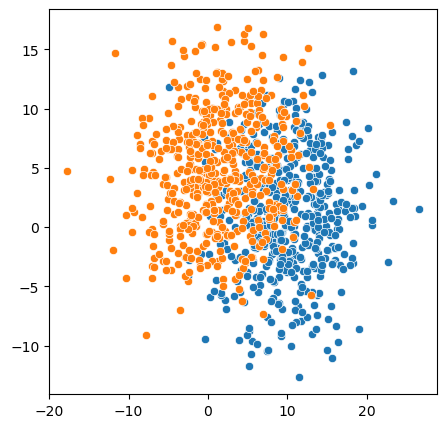

In [16]:
plt.figure(figsize=(5,5))
sns.scatterplot(x = class1_x, y = class1_y)
sns.scatterplot(x=class2_x, y = class2_y)


In [18]:
## Join both classes in a single dataframe and split the train and test sets
df_class1 = pd.DataFrame()
df_class1['x'] = class1_x
df_class1['y'] = class1_y
df_class1['class'] = 0
df_class1.head

<bound method NDFrame.head of              x          y  class
0    13.505913  -3.467231      0
1     5.365132   4.832683      0
2    12.628718   0.087367      0
3     9.517379   6.750553      0
4     6.880059   0.534004      0
..         ...        ...    ...
495  10.039541  10.541704      0
496   8.493691   7.163185      0
497   7.101635  -1.449720      0
498   7.946708  -6.261636      0
499   4.145733   3.022689      0

[500 rows x 3 columns]>

In [22]:
df_class2 = pd.DataFrame()
df_class2['x'] = class2_x
df_class2['y'] = class2_y
df_class2['class'] = 1
df_class2.head

<bound method NDFrame.head of             x          y  class
0   -6.995135  11.034621      1
1    2.325701   5.743413      1
2   -2.148914   7.783100      1
3    0.044148   2.983407      1
4    1.953194   4.661558      1
..        ...        ...    ...
495  6.840945  -1.289413      1
496  6.207797   3.645973      1
497  5.105005  16.787670      1
498  5.755488   3.956852      1
499 -5.264147   6.640746      1

[500 rows x 3 columns]>

In [23]:
df = pd.concat([df_class1,df_class2], ignore_index = True)
print(df.head)
print(df.tail)

<bound method NDFrame.head of              x          y  class
0    13.505913  -3.467231      0
1     5.365132   4.832683      0
2    12.628718   0.087367      0
3     9.517379   6.750553      0
4     6.880059   0.534004      0
..         ...        ...    ...
995   6.840945  -1.289413      1
996   6.207797   3.645973      1
997   5.105005  16.787670      1
998   5.755488   3.956852      1
999  -5.264147   6.640746      1

[1000 rows x 3 columns]>
<bound method NDFrame.tail of              x          y  class
0    13.505913  -3.467231      0
1     5.365132   4.832683      0
2    12.628718   0.087367      0
3     9.517379   6.750553      0
4     6.880059   0.534004      0
..         ...        ...    ...
995   6.840945  -1.289413      1
996   6.207797   3.645973      1
997   5.105005  16.787670      1
998   5.755488   3.956852      1
999  -5.264147   6.640746      1

[1000 rows x 3 columns]>


In [24]:
y = df['class']
x = df.drop(columns=['class'])

In [29]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.25)

In [26]:
## classifcation task

from sklearn.naive_bayes import GaussianNB

In [27]:
# Create the model object
model = GaussianNB()

In [30]:
# Fit the model to the training data
model.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [31]:
# Predict the classes on the test data
y_pred = model.predict(X_test)

In [32]:
# Show the first 10 entries
y_pred[:10]

array([0, 0, 0, 1, 0, 0, 1, 1, 1, 0])

In [33]:
# Predict the classes on the test data, and return the probabilities for each class
y_proba = model.predict_proba(X_test)

In [34]:
# Show the first 10 entries
y_proba[:10]

array([[0.71512182, 0.28487818],
       [0.94797694, 0.05202306],
       [0.70572137, 0.29427863],
       [0.05673021, 0.94326979],
       [0.64756458, 0.35243542],
       [0.820938  , 0.179062  ],
       [0.00388483, 0.99611517],
       [0.03268232, 0.96731768],
       [0.42121379, 0.57878621],
       [0.65656533, 0.34343467]])

<Axes: xlabel='x', ylabel='y'>

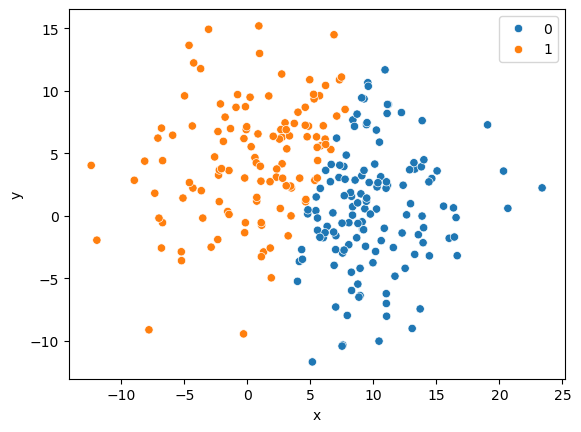

In [35]:
# Show the predictions
sns.scatterplot(x = X_test['x'], y = X_test['y'], hue = y_pred)

### Plot the ROC

In [36]:
from sklearn.metrics import confusion_matrix

In [41]:
def calculate_tpr_fpr(y_real, y_pred):
    # Calculates the confusion matrix and recover each element
    pass
    cm = confusion_matrix(y_real, y_pred)
    TN = cm[0, 0]
    FP = cm[0, 1]
    FN = cm[1, 0]
    TP = cm[1, 1]

    tpr =  TP/(TP + FN)
    fpr = 1 - TN/(TN + FP)

    return tpr, fpr

In [42]:
def get_n_roc_coordinates(y_real, y_proba, resolution = 50):
    '''
    Calculates "n" ROC Curve coordinates (tpr and fpr) by manipulating the threshold used to predict the class.
    
    Args:
        y_real: The list or series with the real classes.
        y_proba: The array with the probabilities for each class, obtained by using the `.predict_proba()` method.
        resolution: Defines how many divisions the threshold will have, and how many coordinates will be calculated (default = 50).
        
    Returns:
        tpr_list: The list of TPRs representing each threshold.
        fpr_list: The list of FPRs representing each threshold.
    '''
    tpr_list = [0]
    fpr_list = [0]
    for i in range(resolution):
        threshold = i/resolution
        y_pred = y_proba[:, 1] > threshold
        tpr, fpr = calculate_tpr_fpr(y_real, y_pred)
        tpr_list.append(tpr)
        fpr_list.append(fpr)
    return tpr_list, fpr_list

In [43]:
def plot_roc_curve(tpr, fpr, scatter = True):
    '''
    Plots the ROC Curve by using the list of coordinates (tpr and fpr).
    
    Args:
        tpr: The list of TPRs representing each coordinate.
        fpr: The list of FPRs representing each coordinate.
        scatter: When True, the points used on the calculation will be plotted with the line (default = True).
    '''
    plt.figure(figsize = (5, 5))
    if scatter:
        sns.scatterplot(x = fpr, y = tpr)
    sns.lineplot(x = fpr, y = tpr)
    sns.lineplot(x = [0, 1], y = [0, 1], color = 'green')
    plt.xlim(-0.05, 1.05)
    plt.ylim(-0.05, 1.05)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

In [44]:
# Calculates 10 coordinates of the ROC Curve
tpr, fpr = get_n_roc_coordinates(y_test, y_proba, resolution = 10)

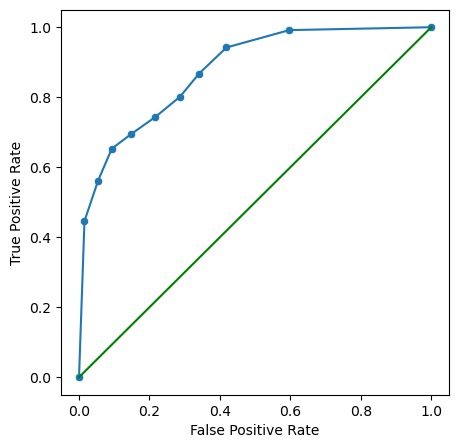

In [45]:
# Plots the ROC curve
plot_roc_curve(tpr, fpr)

In [46]:
def get_all_roc_coordinates(y_real, y_proba):
    '''
    Calculates all the ROC Curve coordinates (tpr and fpr) by considering each point as a treshold for the predicion of the class.
    
    Args:
        y_real: The list or series with the real classes.
        y_proba: The array with the probabilities for each class, obtained by using the `.predict_proba()` method.
        
    Returns:
        tpr_list: The list of TPRs representing each threshold.
        fpr_list: The list of FPRs representing each threshold.
    '''
    tpr_list = [0]
    fpr_list = [0]
    for i in range(len(y_proba)):
        threshold = y_proba[i, 1]
        y_pred = y_proba[:, 1] >= threshold
        tpr, fpr = calculate_tpr_fpr(y_real, y_pred)
        tpr_list.append(tpr)
        fpr_list.append(fpr)
    return tpr_list, fpr_list

In [47]:
# Calculates ALL coordinates of the ROC Curve
tpr, fpr = get_all_roc_coordinates(y_test, y_proba)

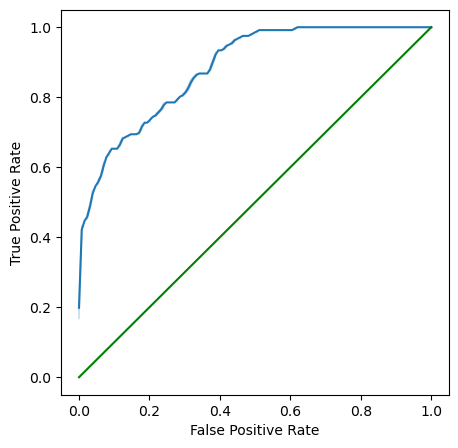

In [48]:
# Plots the ROC curve
plot_roc_curve(tpr, fpr, scatter = False)

In [49]:
## ROC using sklearn

In [50]:
from sklearn.metrics import roc_curve
from sklearn.metrics import RocCurveDisplay

In [51]:
def plot_sklearn_roc_curve(y_real, y_pred):
    '''
    Plots the ROC Curve with the sklearn methods by using the real observations and their predictions.
    
    Args:
        y_real: The list or series with the real classes
        y_pred: The list or series with the predicted classes
    '''
    fpr, tpr, _ = roc_curve(y_real, y_pred)
    roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr).plot()
    roc_display.figure_.set_size_inches(5,5)

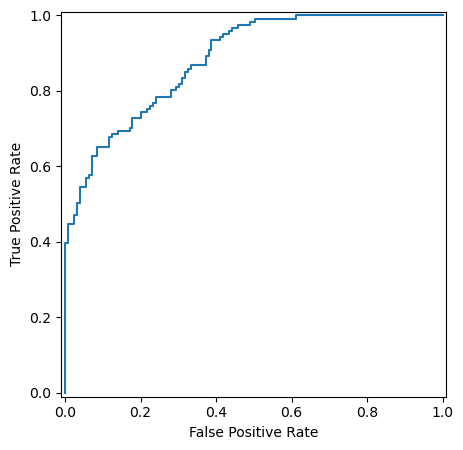

In [52]:
# Plots the ROC curve using the sklearn methods
plot_sklearn_roc_curve(y_test, y_proba[:, 1])

In [53]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

In [54]:
def evaluate_classifier(y_real, y_pred):
    '''
    Prints the accuracy, precision, recall and roc auc scores for the classifier.
    
    Args:
        y_real: The list or series with the real classes
        y_pred: The list or series with the predicted classes
    '''
    print(f"Accuracy: {accuracy_score(y_real, y_pred):.4f}")
    print(f"Precision: {precision_score(y_real, y_pred):.4f}")
    print(f"Recall: {recall_score(y_real, y_pred):.4f}")
    print(f"ROC AUC: {roc_auc_score(y_real, y_pred):.4f}")

In [55]:
evaluate_classifier(y_test, y_pred)

Accuracy: 0.7640
Precision: 0.7627
Recall: 0.7438
ROC AUC: 0.7634
